# Упражнение 3.2

In [7]:
from thinkdsp import Chirp, Sinusoid
import numpy as np

# Если у вас SawtoothSignal уже определён — эту ячейку можно не выполнять.
class SawtoothSignal(Sinusoid):
    def evaluate(self, ts):
        return 2 * (ts * self.freq - np.floor(ts * self.freq + 0.5))

class SawtoothChirp(Chirp):
    """Пилообразный чирп с линейным изменением частоты от start до end за duration."""
    def evaluate(self, ts):
        k = (self.end - self.start) / 2
        cycles = self.start * ts + 0.5 * k * ts**2
        return self.amp * 2 * (cycles - np.floor(cycles + 0.5))

In [8]:
signal = SawtoothChirp(start=440, end=660, amp=2.0)
wave = signal.make_wave(framerate=22050)
wave.make_audio()

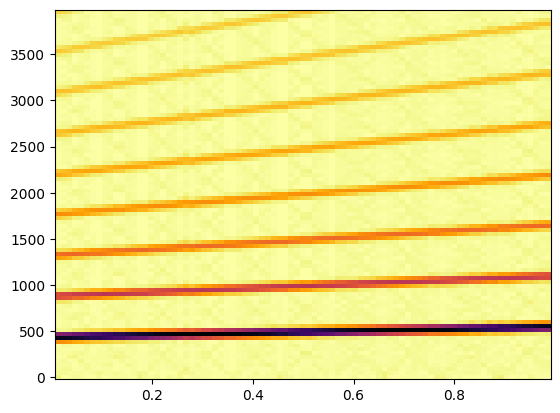

In [9]:
spectrogram = wave.make_spectrogram(seg_length=512)
spectrogram.plot(high=4000)

из-за множества гармоник у пилы на спектрограмме несколько гармоник, и на слух заметные биения.

# Упражнение 3.3


- Поскольку это пила, в сигнале есть гармоники.
- Чирп нестационарный и частота размазана по диапазону.
- При `framerate=20000` полосы:
  - 2500–3000 (1-я),
  - 5000–6000 (2-я),
  - 7500–9000 (3-я)

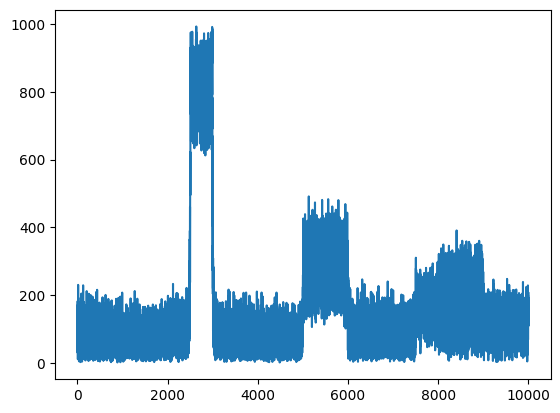

In [23]:
signal = SawtoothChirp(start=2500, end=3000, amp=2.0)
wave = signal.make_wave(framerate=20000, duration=2.0)

spectrum = wave.make_spectrum()
spectrum.plot(high=10000)

# Упражнение 3.4

Найдите или запишите звук **глиссандо** и распечатайте спектрограмму первых нескольких секунд.

Положите WAV рядом с блокнотом и укажите имя файла ниже.
⚠️ Если файл стерео — можно сначала сделать моно (`wave = wave.make_mono()`).

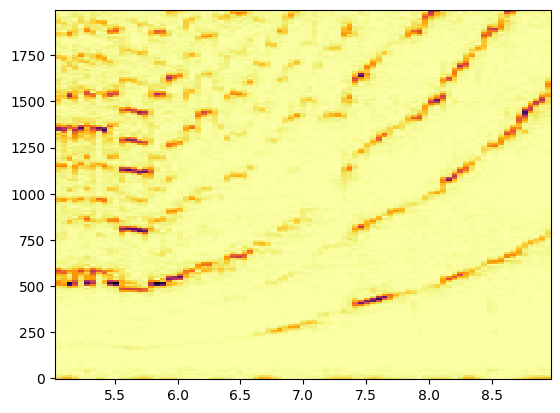

In [36]:
from thinkdsp import read_wave

filename = 'rhapblue11924.wav'   # ваш файл
wave = read_wave(filename)

wave3 = wave.segment(start=5, duration=4)

spectrogram = wave3.make_spectrogram(seg_length=1024)
spectrogram.plot(high=2000)

In [37]:
wave3.make_audio()

# Упражнение 3.5

Если `L(t) = L0 + v t`, то `f(t) = K / (L0 + v t)` - это нелинейный чирп.

C3=262 Гц до F3=349 Гц

In [79]:
from thinkdsp import Chirp
import numpy as np

class TromboneGliss(Chirp):
    """Глиссандо тромбона: 1/f(t) линейно по времени."""
    def evaluate(self, ts):
        f1, f2, T = self.start, self.end, 1
        A = 1.0 / f1
        B = (1.0 / f2 - 1.0 / f1) / T

        if abs(B) < 1e-12:
            cycles = f1 * ts
        else:
            cycles = (1.0 / B) * np.log((A + B * ts) / A)

        return self.amp * np.cos(2 * np.pi * cycles)

In [82]:
up = TromboneGliss(start=262, end=349, amp=1.0)
wave_up = up.make_wave(framerate=20000, duration=1.0)

down = TromboneGliss(start=349, end=262, amp=1.0)
wave_down = down.make_wave(framerate=20000, duration=1.0)

try:
    wave = wave_down | wave_up
except TypeError:
    from thinkdsp import Wave
    ys = np.concatenate([wave_up.ys, wave_down.ys])
    wave = Wave(ys, framerate=wave_up.framerate)

wave.make_audio()

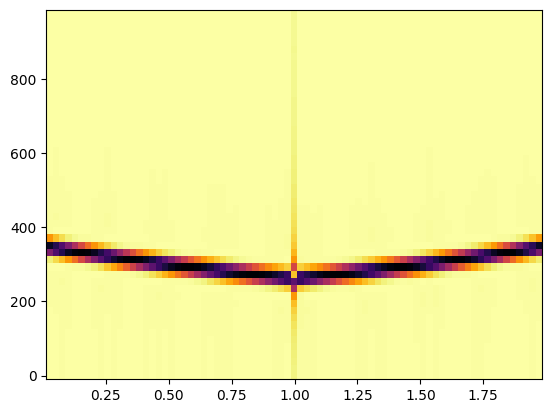

In [83]:
spectrogram = wave.make_spectrogram(seg_length=1024)
spectrogram.plot(high=1000)

На спектрограмме — не прямая как у линейного чирпа, ближе к экспоненчиальному

# Упражнение 3.6

Сделайте/найдите запись серии **гласных** и посмотрите спектрограмму. Гласные различаются **формантами** (устойчивые полосы энергии).

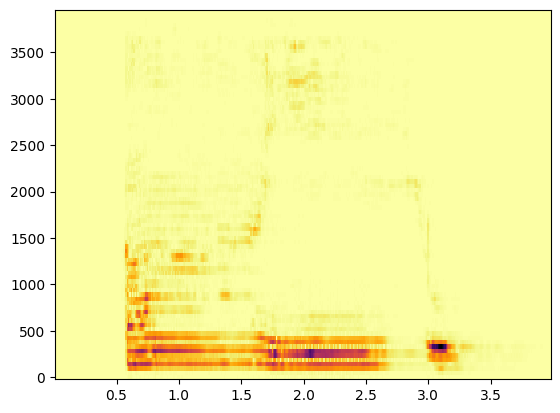

In [ ]:
from thinkdsp import read_wave

filename = 'Recording.wav'
wave = read_wave(filename)

waveN = wave.segment(start=0, duration=4)

spectrogram = waveN.make_spectrogram(seg_length=1024)
spectrogram.plot(high=4000)

тут записал АА-ИИ-УУ

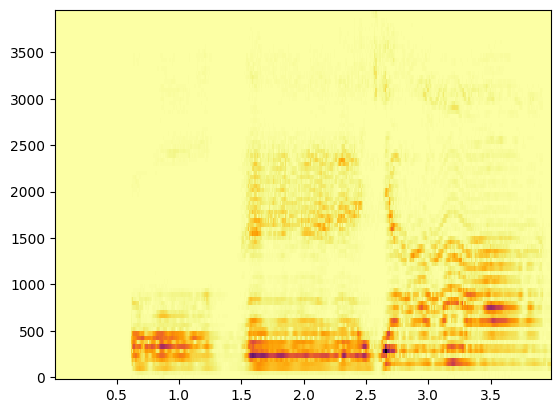

In [86]:
filename = 'Recording2.wav'
wave = read_wave(filename)

waveN = wave.segment(start=0, duration=4)

spectrogram = waveN.make_spectrogram(seg_length=1024)
spectrogram.plot(high=4000)

тут записал ОО-ЭЭ-ЯЯ